# BlinkIT Grocery Sales Analysis

## Introduction

This project focuses on analyzing grocery sales data from BlinkIT. The goal is to explore sales patterns, understand outlet performance, and identify key factors contributing to revenue.

## Dataset Column Description
The dataset contains the following columns:
- Item Fat Content- 
Indicates whether the product is Low Fat or Regular.

- Item Identifier- 
Unique identification number assigned to each product.

- Item Type- 
Category of the product (e.g., Dairy, Snacks, Frozen Foods, etc.).

- Outlet Establishment Year- 
The year in which the outlet was established.

- Outlet Identifier- 
Unique identification number assigned to each outlet/store.

- Outlet Location Type- 
Tier classification of the outlet location (Tier 1, Tier 2, Tier 3).

- Outlet Size- 
Size category of the outlet (Small, Medium, High).

- Outlet Type- 
Type of outlet (e.g., Supermarket Type1, Grocery Store, etc.).

- Item Visibility- 
Represents the percentage of total display area allocated to a particular product in the store.

- Item Weight- 
The weight of the product in kilograms.

- Sales- 
Total sales generated by the product in that particular outlet.

- Rating- 
Customer rating given to the product.

## The goal of this analysis is to:

- Understand sales performance across different outlets
- Identify key factors influencing sales
- Analyze rating impact on revenue
- Generate actionable business insights

### Import the required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

### Importing the dataset

In [2]:
blinkit = pd.read_excel(r"C:\Users\nirma\Downloads\BlinkIT Grocery Data.xlsx")
blinkit.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


### Data Understanding

In [3]:
print(blinkit.shape)
print(blinkit.info())
print(blinkit.describe())

(8523, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB
None
       Outlet Establishment Y

### Data Cleaning & Preprocessing

In [4]:
# Finding the Duplicates
blinkit.duplicated().sum()

0

In [5]:
# Checking for Missing Values
blinkit.isna().sum()

Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64

In [6]:
# Standardized inconsistent values in Item Fat Content column to ensure accurate category-level aggregation.
blinkit['Item Fat Content'].value_counts()
blinkit['Item Fat Content'] = blinkit['Item Fat Content'].replace({'LF':'Low Fat','low fat':'Low Fat', 'reg':'Regular'})
blinkit['Item Fat Content'].unique()

array(['Regular', 'Low Fat'], dtype=object)

### Business KPIs

In [7]:
print("Total Sales:", blinkit['Sales'].sum())
print("Average Sales:", blinkit['Sales'].mean())
print("Number of Items:", blinkit['Sales'].count())
print("Average Rating:", blinkit['Rating'].mean())

Total Sales: 1201681.4928
Average Sales: 140.99278338613163
Number of Items: 8523
Average Rating: 3.965857092573038


### Exploratory Data Analysis (EDA)

### 1. Sales Distribution Analysis

<Axes: xlabel='Sales', ylabel='Count'>

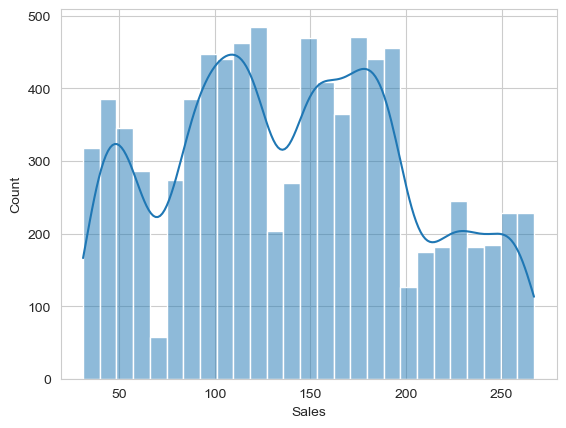

In [8]:
sns.histplot(blinkit['Sales'], kde=True)

### 2.Total Sales by Fat Content:

(This visualization shows how total revenue is distributed between Low Fat and Regular products, helping identify customer preference trends.)

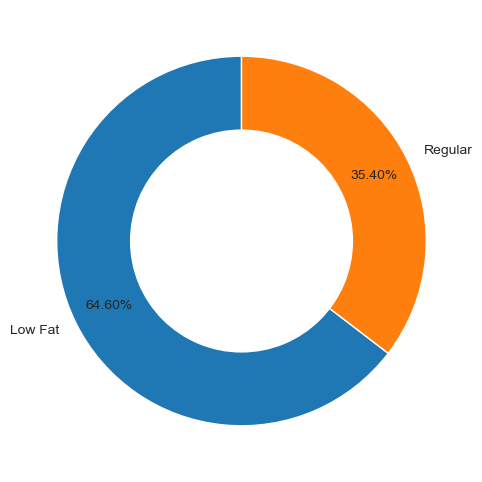

In [10]:
sale_by_fat = blinkit.groupby('Item Fat Content')['Sales'].sum()
fig = plt.subplots(figsize= (6,6))
plt.pie(sale_by_fat, labels = sale_by_fat.index, autopct = '%0.2f%%', pctdistance=0.80, startangle = 90)
plt.pie([1], radius = 0.6, colors = 'white')
plt.show()

Low Fat products contribute nearly 65% of total sales revenue, indicating strong customer preference toward healthier options and establishing this category as the primary revenue driver.

### 3.Total Sales by Item Type:

(This plot highlights the highest revenue-generating product categories, helping the business focus on strong-performing segments.)

C:\Users\nirma\AppData\Local\Temp\ipykernel_11428\1366919430.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = sale_by_item_type.index, y = sale_by_item_type.values, palette = 'viridis')


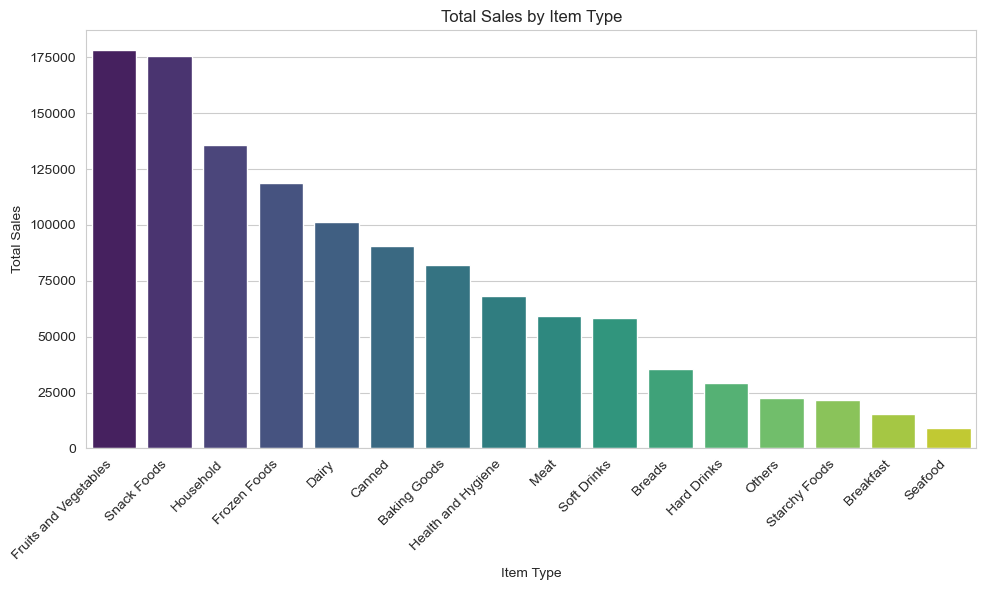

In [10]:
sale_by_item_type = blinkit.groupby('Item Type')['Sales'].sum().sort_values(ascending = False)

plt.figure(figsize=(10,6))
sns.barplot(x = sale_by_item_type.index, y = sale_by_item_type.values, palette = 'viridis')
plt.xticks(rotation = 45, ha = 'right')
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
plt.title('Total Sales by Item Type')
plt.tight_layout()
plt.show()

### 4.Total Sales by Outlet Establishment:

(This plot analyzes whether older outlets generate more sales compared to newly established outlets.)

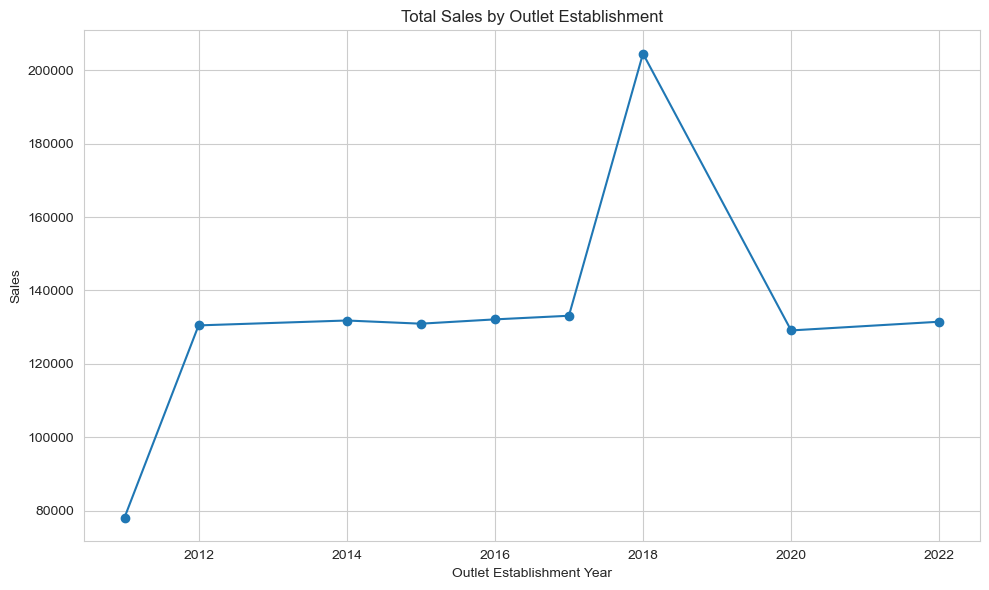

In [12]:
sale_by_year = blinkit.groupby('Outlet Establishment Year')['Sales'].sum()
plt.figure(figsize=(10,6))
plt.plot(sale_by_year.index, sale_by_year.values, marker = 'o')
plt.xlabel('Outlet Establishment Year')
plt.ylabel('Sales')
plt.title('Total Sales by Outlet Establishment')
plt.grid(True)
plt.tight_layout()
plt.show()

Outlets established in 2018 generated the highest total sales, significantly outperforming other years and indicating a particularly successful expansion phase during that period.

### 5. Correlation Analysis: Rating vs Sales

In [12]:
blinkit[['Rating','Sales']].corr()

,Rating,Sales
Rating,1.000000,0.011329
Sales,0.011329,1.000000


Insight:

The correlation coefficient between Rating and Sales is 0.011, which indicates almost no linear relationship between the two variables.

Percentage of ratings >= 4.0: 76.39%


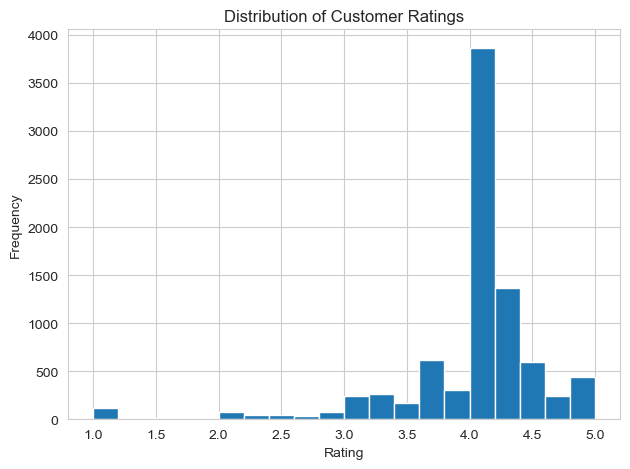

In [13]:
# Customer Rating Distribution Analysis
total = len(blinkit)
high_ratings = blinkit[blinkit['Rating'] >= 4.0]
high_percentage = (len(high_ratings) / total) * 100
print(f"Percentage of ratings >= 4.0: {high_percentage:.2f}%")


plt.figure()
plt.hist(blinkit['Rating'], bins=20)
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Customer Ratings")
plt.tight_layout()
plt.show()

Approximately 76.39% of products have ratings ≥ 4.0, indicating that the majority of products receive high customer satisfaction scores.
The histogram shows that ratings are heavily concentrated in the 4.0–4.5 range, suggesting a generally positive customer perception across products.

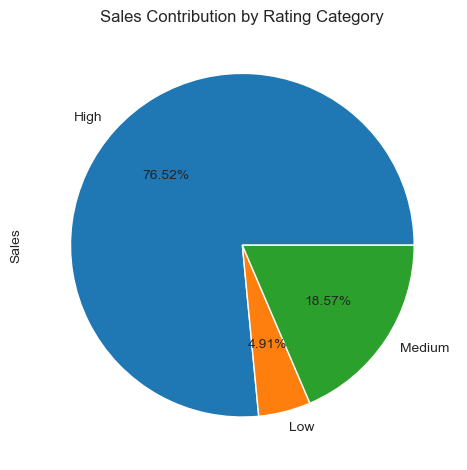

In [14]:
# Sales Contribution by Rating Category
def rating_category(x):
    if x >= 4:
        return "High"
    elif x >= 3:
        return "Medium"
    else:
        return "Low"

blinkit['Rating_Category'] = blinkit['Rating'].apply(rating_category)
sales_percent  = round((blinkit.groupby('Rating_Category')['Sales'].sum()/ blinkit['Sales'].sum())*100, 2)
sales_percent.plot(kind = 'pie', autopct = '%0.2f%%')
plt.title('Sales Contribution by Rating Category')
plt.tight_layout()
plt.show()

- High-rated products contribute 76.52% of total sales.

- Medium-rated products contribute 18.57%.

- Low-rated products contribute only 4.91%.

Although high-rated products contribute the majority of sales, this aligns closely with their proportion in the dataset (76.39%), and the correlation analysis confirms that rating alone is not a strong predictor of sales.

### 6.Total Sales by Outlet Type and Outlet Size
(This pivot table compares total sales across outlet types and sizes to determine performance patterns.)

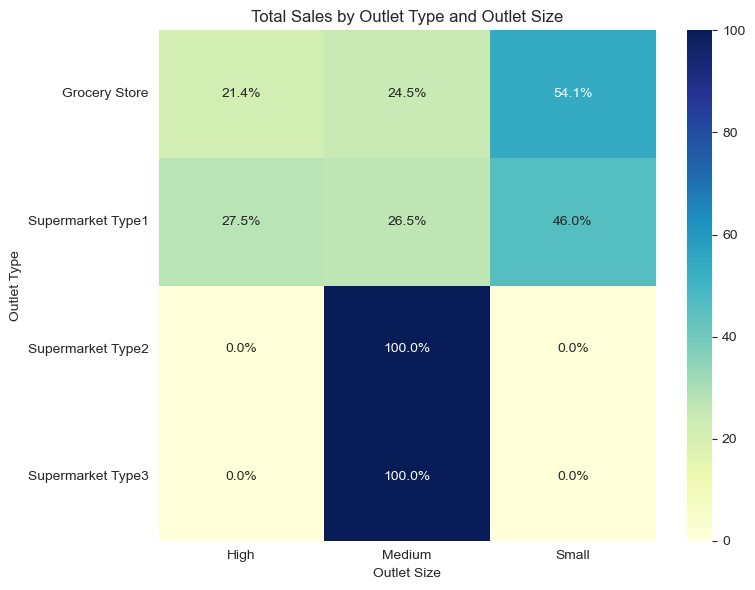

In [15]:
# This pivot table compares total sales across outlet types and sizes to determine performance patterns.
pivot_table = pd.pivot_table(blinkit, values='Sales',index='Outlet Type',columns='Outlet Size',aggfunc='sum')
pivot_table = pivot_table.div(pivot_table.sum(axis=1), axis=0) * 100
pivot_table = pivot_table.fillna(0)
plt.figure(figsize=(8,6))

sns.heatmap(pivot_table, annot=True, fmt='.1f',cmap='YlGnBu')
plt.title('Total Sales by Outlet Type and Outlet Size')
plt.ylabel('Outlet Type')
plt.xlabel('Outlet Size')

for text in plt.gca().texts:
    text.set_text(text.get_text() + "%")

plt.tight_layout()
plt.show()

Insights:
- Small outlets dominate in Grocery Stores (54.09%) and Supermarket Type1 (46.04%), indicating these formats rely heavily on smaller store sizes.
- Supermarket Type2 and Type3 operate exclusively in Medium-sized outlets (100%), showing a standardized store size strategy.
- High-size outlets are limited overall, with the highest presence in Supermarket Type1 (27.48%).
- Grocery Stores have the highest proportion of Small outlets, suggesting they focus more on compact neighborhood stores.
- Medium-sized outlets are the most consistent format across supermarket categories, especially Type2 and Type3.

### 7.Total Sales by Location Tier and Outlet Type 

(Tier 1 vs Tier 2 vs Tier 3 performance)

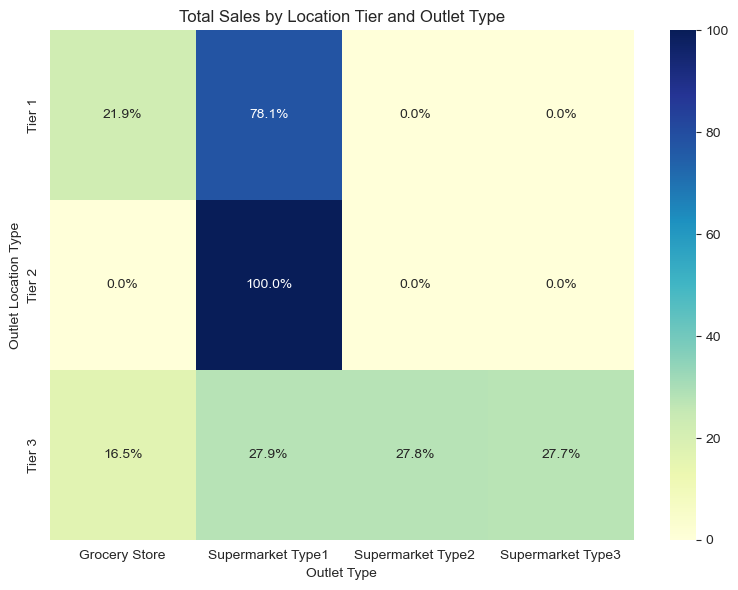

In [16]:
pivot_loc_type = pd.pivot_table(blinkit, values='Sales', index='Outlet Location Type', columns='Outlet Type',aggfunc='sum')
pivot_loc_type = pivot_loc_type.fillna(0)
pivot_loc_type = pivot_loc_type.div(pivot_loc_type.sum(axis=1), axis=0) * 100

plt.figure(figsize=(8,6))
sns.heatmap(pivot_loc_type,annot=True,fmt='.1f',cmap='YlGnBu')
plt.title('Total Sales by Location Tier and Outlet Type')
plt.ylabel('Outlet Location Type')
plt.xlabel('Outlet Type')

for text in plt.gca().texts:
    text.set_text(text.get_text() + "%")

plt.tight_layout()
plt.show()

Insights: 

- Tier 1 is dominated by Supermarket Type1 (78%), indicating a strong presence of organized retail in high-income, metropolitan areas.
- Tier 2 is fully captured by Supermarket Type1 (100%), suggesting it is the primary expansion model in developing urban markets.
- Tier 3 shows the most diversified retail presence, with Grocery Stores (16.5%), Supermarket Type1 (27.9%), Supermarket Type2 (27.8%), and Supermarket Type3 (27.7%) — indicating intense competition in smaller cities.
- Supermarket Type2 and Type3 operate exclusively in Tier 3 locations, implying a strategic focus on semi-urban or price-sensitive markets.
- Grocery Stores have presence in Tier 1 and Tier 3, but no presence in Tier 2, suggesting selective expansion based on demand structure.

### 8.Total Sales by Item Type and Fat Content

(Which categories drive sales in Low Fat vs Regular.)

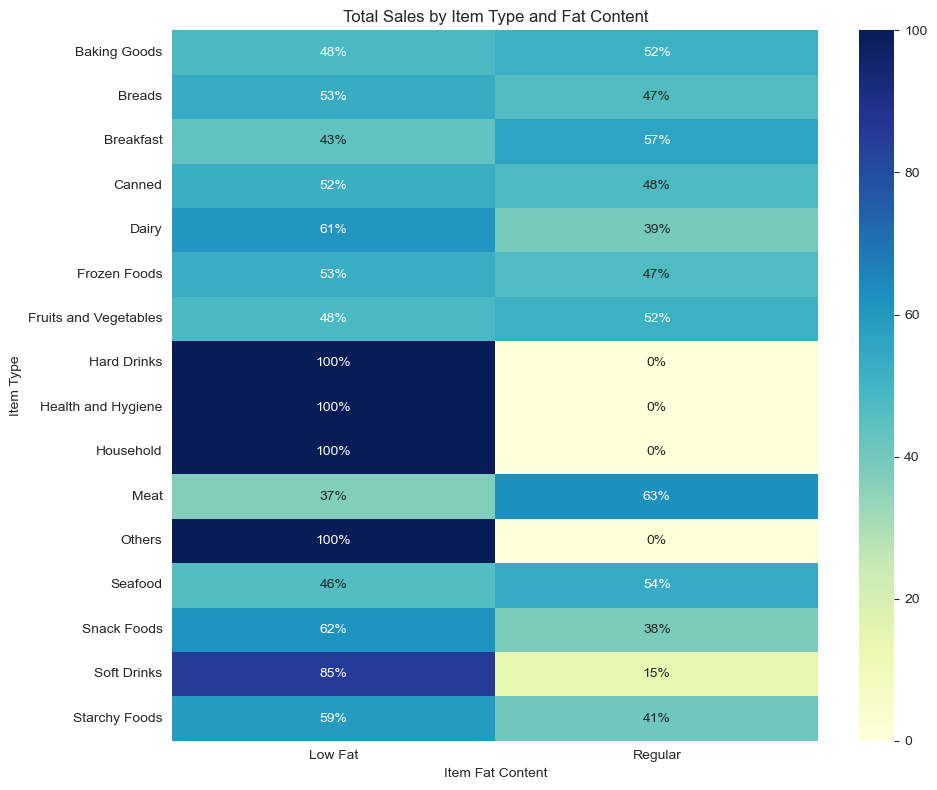

In [13]:
pivot_item_fat = pd.pivot_table(blinkit,values='Sales',index='Item Type',columns='Item Fat Content',aggfunc='sum')
pivot_item_fat = pivot_item_fat.fillna(0)
pivot_item_fat = pivot_item_fat.div(pivot_item_fat.sum(axis=1),axis=0) * 100

plt.figure(figsize=(10,8))
sns.heatmap(pivot_item_fat,annot=True,fmt='.0f',cmap='YlGnBu')
plt.title('Total Sales by Item Type and Fat Content')
plt.ylabel('Item Type')
plt.xlabel('Item Fat Content')

for text in plt.gca().texts:
    text.set_text(text.get_text() + "%")

plt.tight_layout()
plt.show()

Insights:
- Health-oriented products (Hard Drinks, Health & Hygiene, Household, Others) are entirely Low Fat, showing a clear positioning toward health-conscious consumers.
- Dairy products are largely Low Fat (60.7%), reflecting consumer preference for healthier options in everyday staples.
- Staple foods like Breads, Canned, Frozen, Fruits & Vegetables have a balanced Low vs Regular Fat split, indicating diverse customer preferences.
- Snack Foods and Starchy Foods favor Low Fat (61–59%), highlighting a trend toward healthier indulgences.
- Meat and Seafood show higher Regular Fat consumption, suggesting traditional taste preferences dominate in protein-rich categories.
- Soft Drinks are predominantly Low Fat (85%), likely due to the rising demand for diet or low-calorie beverages.

### 9. Sales by Location, Size and Outlet Type

(This table shows how sales vary by outlet type across different location tiers and outlet sizes to identify high-performing combinations.)

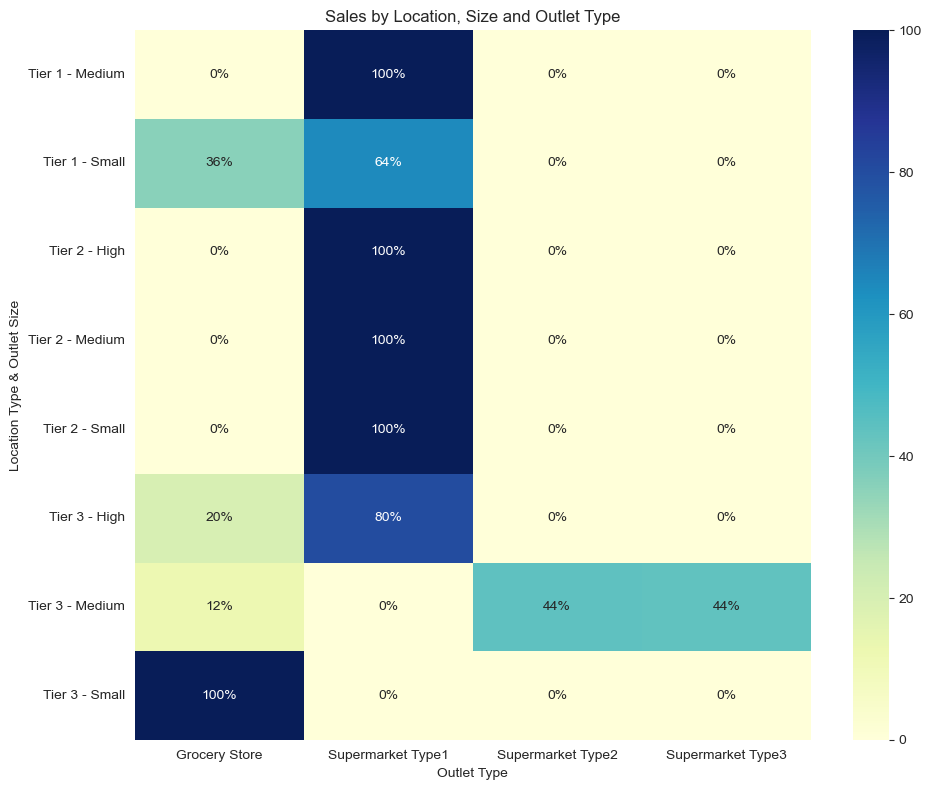

In [14]:
pivot_three = pd.pivot_table(blinkit,values='Sales',index=['Outlet Location Type','Outlet Size'],columns='Outlet Type',
                             aggfunc='sum')
pivot_three = pivot_three.fillna(0)
pivot_three = pivot_three.div(pivot_three.sum(axis=1),axis=0) * 100
pivot_three.index = [f"{loc} - {size}" for loc, size in pivot_three.index]

plt.figure(figsize=(10,8))
sns.heatmap(pivot_three,annot=True,fmt='.0f',cmap='YlGnBu')
plt.title('Sales by Location, Size and Outlet Type')
plt.ylabel('Location Type & Outlet Size')
plt.xlabel('Outlet Type')

for text in plt.gca().texts:
    text.set_text(text.get_text() + "%")
    
plt.tight_layout()
plt.show()

Insights: 
- Supermarket Type1 dominates Tier 1 and Tier 2 across all sizes, showing a strong presence in urban and semi-urban markets with a flexible store size strategy.
- Grocery Stores in Tier 1 and Tier 3 focus mostly on Small and Medium outlets, indicating a neighborhood-focused approach.
- Grocery Stores operate in all sizes, with Small outlets at 100% in Tier 3, targeting local demand.
- Supermarket Type2 and Type3 operate only in Medium outlets (43–44%), reflecting a standardized format for semi-urban areas.
- High-size outlets are limited and appear mostly in Supermarket Type1 in Tier 3 (19.8%), indicating selective investment in large-format stores.
- No presence of Supermarket Type2 and Type3 in Tier 1 and Tier 2, highlighting a tier-based market segmentation strategy, where these formats target only Tier 3 locations.

### 10.Correlation Matrix of Numerical Variables

<Axes: >

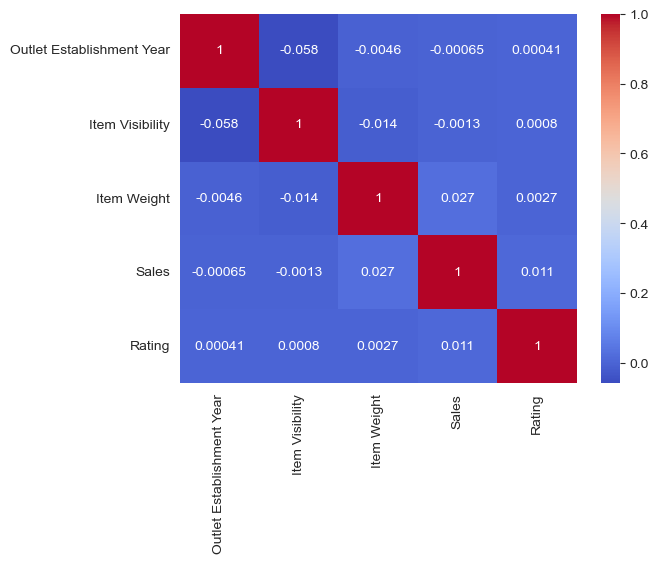

In [19]:
sns.heatmap(blinkit.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')

Insight:

The correlation heatmap shows that all numerical variables have correlation values close to zero. This indicates that there is no strong linear relationship between sales and other numerical factors.

## Final Conclusion

- The correlation between product rating and individual product sales is very weak, indicating that rating alone is not a strong predictor of sales performance at the product level.

- However, when sales are analyzed in aggregated form, high-rated products contribute a larger share of total revenue. This suggests that while rating does not directly drive individual sales, overall product quality and customer perception may support stronger business performance collectively.

- Outlet type plays a significant role in revenue generation, with supermarket formats outperforming grocery stores in total sales contribution.

- Location tier segmentation shows variation in outlet performance, indicating that geographic factors influence revenue distribution.

- Certain item categories contribute disproportionately to total sales, suggesting the importance of inventory optimization and category-level strategic focus.